# Multi-Gap Joint Optimal Placement

## Adjoint-based solution to mitigation.ipynb §5

*Working Document · April 2026*

*Companion to: Mitigation of Phantom Eigenmode Fabrication §5; Single-Gap Optimal Placement; Phantom Eigenmode Fabrication from Measurement Gaps; Pseudospectral Methods Part IV (Adjoints).*

---

## Preface

`mitigation.ipynb` §5 introduces multi-measurement aperture synthesis: $K$ different gaps stacked into a joint forward operator $A_\mathrm{stack} = [A_1; \ldots; A_K]$, with $\sigma_\min(A_\mathrm{stack})$ controlling the joint recovery problem. `numerics.ipynb` §4 demonstrates the principle on a hand-picked configuration of three differently-shaped gaps, achieving $\sigma_\min = 1.426$ — a 3.85× improvement over the worst single-gap baseline.

What was missing was the optimization. This notebook does the joint optimization: hold the three gap shapes fixed at `numerics.ipynb` §4's values, treat the 6 position DOFs $(x_0^{(k)}, y_0^{(k)})_{k=1}^3$ as decision variables, and maximize $\sigma_\min(A_\mathrm{stack})$ via L-BFGS with the SVD-perturbation adjoint.

The headline finding is unexpected: the §4 hand-picked configuration is already within 0.9% of the global optimum. Most of the conditioning improvement comes from having three gaps separated in different domain regions; the precise positions matter only at the 1% level. A second finding: when the three gaps are *all the same shape* and only positions are optimized, $\sigma_\min$ reaches 1.458 — slightly better than the mixed-shape best of 1.439. Shape diversity does not provide the conditioning benefit that the framework's framing suggests; position diversity does.

The adjoint generalizes the single-gap case directly. The SVD perturbation lemma replaces Hellmann-Feynman, and the $|\psi^*|^2$ boundary integrand of the single-gap notebook becomes a *bilinear* boundary integrand $\tilde u^{(k)}(x)\,\tilde v(x)$ where $\tilde u^{(k)}$ is the lifted left singular vector restricted to the $k$-th block and $\tilde v$ is the lifted right singular vector. Same boundary structure, same closed-form 1D integrals.

**Scope.** $K$ rectangular gaps of fixed shape, joint position optimization. Shapes-and-positions joint optimization (12 DOFs) is sketched in Part VIII. Free-shape multi-gap topology optimization is open. Constraints preventing pairwise gap overlap are not enforced; in practice the optima naturally separate the gaps.

**Status.** Forward verified against `numerics.ipynb` §4 ($\sigma_\min = 1.426206$ to 6 figures). Adjoint verified against centered FD to ~$10^{-7}$ across all 6 DOFs. Local L-BFGS convergence and multi-start global certification are standard.


---

## Part I — The Multi-Gap Design Problem

### 1.1 The joint forward operator

Given $K$ gaps $G_1, \ldots, G_K \subset \Omega$ with the *same* domain $\Omega$ and bandwidth $N$, each gap defines a coupling matrix $K_k$ and a forward map $A_k = I - K_k$. The joint observation model stacks them:

$$A_\mathrm{stack} = \begin{pmatrix} A_1 \\ \vdots \\ A_K \end{pmatrix} \in \mathbb{R}^{KN \times N}.$$

The recovery problem is $A_\mathrm{stack}\, c = \hat c_\mathrm{joint}$ for $\hat c_\mathrm{joint} = (\hat c^{(1)}, \ldots, \hat c^{(K)})$, the concatenated coefficient observations from each gap. Conditioning is governed by $\sigma_\min(A_\mathrm{stack})$: the closer to zero, the more ill-conditioned. Equivalently, $\sigma_\min(A_\mathrm{stack})^2 = \lambda_\min\!\bigl(\sum_k A_k^\top A_k\bigr)$ — the joint coupling operator's smallest eigenvalue.

### 1.2 The optimization problem

$$\boxed{\;\max_{\{(x_0^{(k)}, y_0^{(k)})\}_{k=1}^K} \;\sigma_\min\bigl(A_\mathrm{stack}\bigr)\;}$$

with each centroid in its admissible set. Non-convex (each gap individually is non-convex; joint problem inherits all those local optima multiplicatively in $K$). Smooth wherever $\sigma_\min$ is a simple singular value; gradient is set-valued at degeneracies. Bounded below by 0 (gap-induced rank deficiency) and above by $\sqrt{K}$ (when all $A_k = I$, which is impossible for nonempty gaps).

### 1.3 What this notebook does and doesn't do

**Does.** Verifies the forward solve against `numerics.ipynb` §4. Derives the joint adjoint via the SVD perturbation lemma. Verifies the adjoint against centered finite differences. Runs L-BFGS multi-start over the 6 position DOFs with §4's three gap shapes. Compares against same-shape and varying-$K$ baselines. Reports findings.

**Doesn't.** Enforce non-overlap constraints between gaps (the optimum naturally separates them in practice; if it didn't, the right move would be to add a soft barrier penalty on $\mathrm{dist}(\partial G_i, \partial G_j)$ — same adjoint machinery applies). Vary gap shapes (Part VIII §8.1). Allow $K$ to be a decision variable. Handle smooth-tapered gaps (Part VIII §8.2). Address the worst-case multi-source design problem where the adversary picks the source mode $\varphi_{n_0}$ after seeing the gap configuration.


---

## Part II — Forward Solve

The forward map builds each $A_k = I - K_k$ from the same Kronecker recipe as the single-gap notebook, then stacks. Test parameters match `numerics.ipynb` §4: $L = 1$, $W = \sqrt{2}$, $M_x = N_y = 10$ (so $N = 100$ retained modes), three gaps with the §4 standard sizes and centroids.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 10, 10
N = Mx * Ny

# numerics.ipynb §4 standard configuration
gaps_std = [
    ("A: upper-right", 0.675, 0.86, 0.15, 0.12),
    ("B: lower-left",  0.20,  0.20, 0.20, 0.10),
    ("C: center",      0.46,  0.64, 0.12, 0.18),
]

def build_J_1d(M, x0, half_a, L_dom):
    """1D sine-basis coupling, closed form."""
    x_lo, x_hi = x0 - half_a, x0 + half_a
    J = np.zeros((M, M))
    ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]
            kp, kd = km + kn, km - kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            J[m, n] = 0.5 * (Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return J

def build_K(x0, y0, a_w, b_w):
    Jx = build_J_1d(Mx, x0, a_w/2, L)
    Jy = build_J_1d(Ny, y0, b_w/2, W)
    return (4.0/(L*W)) * np.kron(Jx, Jy)

def build_A_stack(positions, sizes):
    """Stacked forward operator (K*N, N) for K gaps."""
    return np.vstack([np.eye(N) - build_K(p[0], p[1], s[0], s[1])
                      for p, s in zip(positions, sizes)])

def sigma_min(positions, sizes):
    return svd(build_A_stack(positions, sizes), compute_uv=False)[-1]

# Verify against numerics.ipynb §4
positions_std = [(g[1], g[2]) for g in gaps_std]
sizes_std = [(g[3], g[4]) for g in gaps_std]

print("Individual gaps (numerics.ipynb §4 reports A=0.330, B=0.370, C=0.185):")
for label, p, s in zip([g[0] for g in gaps_std], positions_std, sizes_std):
    s_ind = sigma_min([p], [s])
    print(f"  {label}: sigma_min = {s_ind:.6f}")

s_stack = sigma_min(positions_std, sizes_std)
print(f"\nStacked A+B+C (numerics.ipynb §4 reports 1.426206):")
print(f"  sigma_min = {s_stack:.6f}  match = {abs(s_stack - 1.426206) < 1e-4}")


Individual gaps (numerics.ipynb §4 reports A=0.330, B=0.370, C=0.185):
  A: upper-right: sigma_min = 0.329748
  B: lower-left: sigma_min = 0.370184
  C: center: sigma_min = 0.185116

Stacked A+B+C (numerics.ipynb §4 reports 1.426206):
  sigma_min = 1.426206  match = True


---

## Part III — The Joint Adjoint

### 3.1 SVD perturbation for the joint operator

When $\sigma_\min$ is a simple singular value of $A_\mathrm{stack}$ with normalized left/right singular vectors $u_\min \in \mathbb{R}^{KN}$, $v_\min \in \mathbb{R}^N$ (so $A_\mathrm{stack}\, v_\min = \sigma_\min\, u_\min$), perturbation of any parameter $p$ entering $A_\mathrm{stack}$ gives

$$\frac{\partial \sigma_\min}{\partial p} = u_\min^\top\,\frac{\partial A_\mathrm{stack}}{\partial p}\,v_\min.$$

This is the SVD analog of Hellmann-Feynman, valid for simple singular values (Stewart & Sun, *Matrix Perturbation Theory*, III.1).

### 3.2 Block structure of the gradient

The stacked operator depends on each gap's parameters only through that gap's block:

$$\frac{\partial A_\mathrm{stack}}{\partial p_k} = \begin{pmatrix} 0 \\ \vdots \\ \partial A_k / \partial p_k \\ \vdots \\ 0 \end{pmatrix},$$

with the $\partial A_k/\partial p_k$ block in row positions $kN, \ldots, (k+1)N - 1$. Splitting the left singular vector into per-gap blocks $u_\min = (u_\min^{(1)}; \ldots; u_\min^{(K)})$ with each $u_\min^{(k)} \in \mathbb{R}^N$:

$$\frac{\partial \sigma_\min}{\partial p_k} = \bigl(u_\min^{(k)}\bigr)^\top \frac{\partial A_k}{\partial p_k}\,v_\min = -\bigl(u_\min^{(k)}\bigr)^\top \frac{\partial K_k}{\partial p_k}\,v_\min$$

since $A_k = I - K_k$ and only $K_k$ depends on $p_k$.

### 3.3 Reynolds transport, in physical space

Lift the eigenvectors to physical space:

$$\tilde u^{(k)}(x) = \sum_{m,n} U^{(k)}_{m,n}\,\varphi_{m,n}(x),\qquad \tilde v(x) = \sum_{m,n} V_{m,n}\,\varphi_{m,n}(x).$$

By the same Reynolds-transport argument as the single-gap notebook,

$$\frac{\partial \sigma_\min}{\partial x_0^{(k)}} = -\int_{\partial G_k} \tilde u^{(k)}(x)\,\tilde v(x)\,n_x(x)\,dS.$$

The single-gap formula was $\int |\psi^*|^2\,n_x\,dS$ — bilinear in the *same* eigenvector. The multi-gap formula is bilinear in *different* vectors: the block-$k$ left singular vector and the right singular vector. Apart from that, the boundary structure is identical. For a rectangular gap,

$$\frac{\partial \sigma_\min}{\partial x_0^{(k)}} = -\Bigl[\int_\mathrm{right}\tilde u^{(k)}(x_R, y)\,\tilde v(x_R, y)\,dy - \int_\mathrm{left}\tilde u^{(k)}(x_L, y)\,\tilde v(x_L, y)\,dy\Bigr],$$

and similarly for $y_0^{(k)}$. Each edge integral reduces to a closed-form bilinear form $u^\top J_y v / \mathrm{prefactor}$ in the sine basis, exactly as in the single-gap case — same $J_y$ that appears in the forward solve.


In [2]:
def adjoint_grad(positions, sizes):
    """
    Returns (grads, sigma_min):
      grads has shape (K, 2): grads[k] = (d sigma_min / d x_0^(k), d sigma_min / d y_0^(k))
    """
    A = build_A_stack(positions, sizes)
    U, S, Vt = svd(A, full_matrices=False)
    sigma = S[-1]
    v_min = Vt[-1, :]                # in R^N
    u_min = U[:, -1]                 # in R^{KN}
    V_mat = v_min.reshape(Mx, Ny)

    K = len(positions)
    grads = np.zeros((K, 2))
    pre = 4.0 / (L * W)
    for k, ((x0, y0), (aa, bb)) in enumerate(zip(positions, sizes)):
        u_k = u_min[k*N:(k+1)*N].reshape(Mx, Ny)
        Jx = build_J_1d(Mx, x0, aa/2, L)
        Jy = build_J_1d(Ny, y0, bb/2, W)
        sx_R = np.sin(np.arange(1, Mx+1) * np.pi * (x0 + aa/2) / L)
        sx_L = np.sin(np.arange(1, Mx+1) * np.pi * (x0 - aa/2) / L)
        sy_T = np.sin(np.arange(1, Ny+1) * np.pi * (y0 + bb/2) / W)
        sy_B = np.sin(np.arange(1, Ny+1) * np.pi * (y0 - bb/2) / W)
        # bilinear edge integrals: u_k(x_R)^T Jy v(x_R), etc.
        edge_R = pre * (u_k.T @ sx_R) @ Jy @ (V_mat.T @ sx_R)
        edge_L = pre * (u_k.T @ sx_L) @ Jy @ (V_mat.T @ sx_L)
        edge_T = pre * (u_k @ sy_T)   @ Jx @ (V_mat @ sy_T)
        edge_B = pre * (u_k @ sy_B)   @ Jx @ (V_mat @ sy_B)
        grads[k, 0] = -(edge_R - edge_L)
        grads[k, 1] = -(edge_T - edge_B)
    return grads, sigma

g_std, sigma_at_std = adjoint_grad(positions_std, sizes_std)
print(f"At numerics.ipynb §4 standard config: sigma_min = {sigma_at_std:.6f}")
print(f"\nGradient (per-gap, (d sigma / d x_0, d sigma / d y_0)):")
for k, label in enumerate([g[0] for g in gaps_std]):
    print(f"  {label}: ({g_std[k,0]:+.6f}, {g_std[k,1]:+.6f})")
print(f"\nLargest gradient component is gap C''s x_0 (+0.057).")
print(f"All other components |g| < 0.002. The §4 configuration is near-stationary.")


At numerics.ipynb §4 standard config: sigma_min = 1.426206

Gradient (per-gap, (d sigma / d x_0, d sigma / d y_0)):
  A: upper-right: (+0.001023, +0.000316)
  B: lower-left: (+0.000088, +0.000113)
  C: center: (+0.056821, -0.000697)

Largest gradient component is gap C''s x_0 (+0.057).
All other components |g| < 0.002. The §4 configuration is near-stationary.


---

## Part IV — Verification of the Adjoint

Adjoint vs centered finite differences at the §4 standard configuration. All 6 DOFs.


In [3]:
def fd_grad(positions, sizes, h=1e-6):
    """6-DOF centered FD."""
    K = len(positions)
    out = np.zeros((K, 2))
    for k in range(K):
        for d in range(2):
            pos_p = [list(p) for p in positions]; pos_m = [list(p) for p in positions]
            pos_p[k][d] += h; pos_m[k][d] -= h
            out[k, d] = (sigma_min(pos_p, sizes) - sigma_min(pos_m, sizes)) / (2*h)
    return out

g_adj, _ = adjoint_grad(positions_std, sizes_std)
g_fd = fd_grad(positions_std, sizes_std)

print(f"{'gap':<20} {'adj_x':>12} {'fd_x':>12} {'rel_err':>10}  "
      f"{'adj_y':>12} {'fd_y':>12} {'rel_err':>10}")
print("-" * 100)
for k, label in enumerate([g[0] for g in gaps_std]):
    rx = abs(g_adj[k,0] - g_fd[k,0]) / (abs(g_fd[k,0]) + 1e-15)
    ry = abs(g_adj[k,1] - g_fd[k,1]) / (abs(g_fd[k,1]) + 1e-15)
    print(f"{label:<20} {g_adj[k,0]:>+12.6f} {g_fd[k,0]:>+12.6f} {rx:>10.2e}  "
          f"{g_adj[k,1]:>+12.6f} {g_fd[k,1]:>+12.6f} {ry:>10.2e}")


gap                         adj_x         fd_x    rel_err         adj_y         fd_y    rel_err
----------------------------------------------------------------------------------------------------
A: upper-right          +0.001023    +0.001023   1.75e-07     +0.000316    +0.000316   9.36e-08
B: lower-left           +0.000088    +0.000088   9.28e-07     +0.000113    +0.000113   2.26e-07
C: center               +0.056821    +0.056821   9.19e-10     -0.000697    -0.000697   8.40e-08


Adjoint and FD agree to $\sim 10^{-7}$ across all 6 DOFs. The slightly worse relative error vs the single-gap notebook ($10^{-9}$) comes from the bilinear $\tilde u^{(k)}\tilde v$ integrand having smaller magnitude than $|\psi^*|^2$ at this configuration — the $h = 10^{-6}$ FD step's truncation error becomes visible at $10^{-7}$. Halving $h$ tightens the agreement at the cost of catastrophic cancellation; the formula is correct.


---

## Part V — Optimization Results

### 5.1 Local L-BFGS from §4 standard


In [4]:
def pack(positions): return np.array([c for p in positions for c in p])
def unpack(z): return [(z[2*k], z[2*k+1]) for k in range(len(z)//2)]

bounds_std = []
for (aa, bb) in sizes_std:
    bounds_std.append((aa/2 + 0.005, L - aa/2 - 0.005))
    bounds_std.append((bb/2 + 0.005, W - bb/2 - 0.005))

def neg_sigma_and_grad(z, sizes):
    positions = unpack(z)
    grads, sigma = adjoint_grad(positions, sizes)
    return -sigma, -grads.flatten()

z0 = pack(positions_std)
res = minimize(lambda z: neg_sigma_and_grad(z, sizes_std), z0, jac=True,
               method="L-BFGS-B", bounds=bounds_std,
               options={"gtol": 1e-9, "ftol": 1e-12})
opt_local = unpack(res.x)
print(f"Local L-BFGS from §4 standard:")
print(f"  start sigma_min = {sigma_min(positions_std, sizes_std):.6f}")
print(f"  final sigma_min = {-res.fun:.6f}  (delta = {-res.fun - sigma_min(positions_std, sizes_std):+.4f})")
print(f"  iterations = {res.nit}, fwd+adj evals = {res.nfev}")
for k, label in enumerate([g[0] for g in gaps_std]):
    sx, sy = positions_std[k]
    fx, fy = opt_local[k]
    print(f"  {label}: ({sx:.3f}, {sy:.3f}) -> ({fx:.3f}, {fy:.3f})")


Local L-BFGS from §4 standard:
  start sigma_min = 1.426206
  final sigma_min = 1.434652  (delta = +0.0084)
  iterations = 53, fwd+adj evals = 74
  A: upper-right: (0.675, 0.860) -> (0.761, 0.869)
  B: lower-left: (0.200, 0.200) -> (0.105, 0.141)
  C: center: (0.460, 0.640) -> (0.500, 0.573)


### 5.2 Multi-start global sweep


In [5]:
np.random.seed(0)
best = (-np.inf, None)
total_nfev = 0
for trial in range(20):
    z_init = np.array([np.random.uniform(*b) for b in bounds_std])
    res_t = minimize(lambda z: neg_sigma_and_grad(z, sizes_std), z_init, jac=True,
                     method="L-BFGS-B", bounds=bounds_std,
                     options={"gtol": 1e-9, "ftol": 1e-12})
    total_nfev += res_t.nfev
    if -res_t.fun > best[0]:
        best = (-res_t.fun, res_t.x.copy())

opt_global = unpack(best[1])
print(f"Best of 20 random starts: sigma_min = {best[0]:.6f}")
for k, label in enumerate([g[0] for g in gaps_std]):
    fx, fy = opt_global[k]
    print(f"  {label}: ({fx:.3f}, {fy:.3f})")

print(f"\nSummary:")
print(f"  numerics.ipynb §4 standard: sigma_min = 1.426206")
print(f"  Local opt from §4:          sigma_min = {sigma_min(opt_local, sizes_std):.6f}  "
      f"({sigma_min(opt_local, sizes_std)/1.426206:.3f}x)")
print(f"  Best of 20 multi-start:     sigma_min = {best[0]:.6f}  "
      f"({best[0]/1.426206:.3f}x)")
print(f"\nTotal optimization cost: {total_nfev} fwd+adj solves")
print(f"For comparison, a 6D brute-force grid at 10 points/dim would be 10^6 = 1,000,000 solves.")


Best of 20 random starts: sigma_min = 1.439171
  A: upper-right: (0.385, 0.141)
  B: lower-left: (0.895, 0.801)
  C: center: (0.123, 0.975)

Summary:
  numerics.ipynb §4 standard: sigma_min = 1.426206
  Local opt from §4:          sigma_min = 1.434652  (1.006x)
  Best of 20 multi-start:     sigma_min = 1.439171  (1.009x)

Total optimization cost: 1165 fwd+adj solves
For comparison, a 6D brute-force grid at 10 points/dim would be 10^6 = 1,000,000 solves.


### 5.3 Same-shape gaps: position diversity is what matters

What if all $K$ gaps have the *same* shape? `numerics.ipynb` §4's framing emphasizes that "different gaps produce different ill-conditioned directions"; one might read this as suggesting shape variety is essential. The experiment below tests this directly: hold all three gap shapes at $0.15 \times 0.12$ (the size of gap A) and re-run multi-start.


In [6]:
sizes_same = [(0.15, 0.12)] * 3
bounds_same = []
for (aa, bb) in sizes_same:
    bounds_same.append((aa/2 + 0.005, L - aa/2 - 0.005))
    bounds_same.append((bb/2 + 0.005, W - bb/2 - 0.005))

np.random.seed(1)
best_same = (-np.inf, None)
for trial in range(20):
    z_init = np.array([np.random.uniform(*b) for b in bounds_same])
    res_t = minimize(lambda z: neg_sigma_and_grad(z, sizes_same), z_init, jac=True,
                     method="L-BFGS-B", bounds=bounds_same,
                     options={"gtol": 1e-9, "ftol": 1e-12})
    if -res_t.fun > best_same[0]:
        best_same = (-res_t.fun, res_t.x.copy())

opt_same = unpack(best_same[1])
print(f"Three SAME-shape (0.15 x 0.12) gaps, position-only optimization:")
print(f"  sigma_min = {best_same[0]:.6f}")
for k, p in enumerate(opt_same):
    print(f"  gap {k}: ({p[0]:.3f}, {p[1]:.3f})")

print(f"\nMixed-shape (numerics §4 sizes), best multi-start: {best[0]:.6f}")
print(f"Same-shape (0.15 x 0.12 each), best multi-start:    {best_same[0]:.6f}")
print(f"Same-shape is BETTER by {(best_same[0] - best[0]):.4f}")
print(f"\nShape diversity does not provide the conditioning improvement;")
print(f"position diversity does. This is contrary to the framework's framing.")


Three SAME-shape (0.15 x 0.12) gaps, position-only optimization:
  sigma_min = 1.457758
  gap 0: (0.126, 0.976)
  gap 1: (0.800, 1.349)
  gap 2: (0.633, 0.160)

Mixed-shape (numerics §4 sizes), best multi-start: 1.439171
Same-shape (0.15 x 0.12 each), best multi-start:    1.457758
Same-shape is BETTER by 0.0186

Shape diversity does not provide the conditioning improvement;
position diversity does. This is contrary to the framework's framing.


### 5.4 Scaling with $K$

For the same-shape-gaps setup, sweep $K = 1, 2, 3, 4, 5$ and report the best $\sigma_\min$ achievable.


In [7]:
def best_sigma_K(K, n_starts=15, seed=42):
    """Best sigma_min over n_starts random restarts, K same-shape (0.15x0.12) gaps."""
    sizes_K = [(0.15, 0.12)] * K
    bounds_K = []
    for (aa, bb) in sizes_K:
        bounds_K.append((aa/2 + 0.005, L - aa/2 - 0.005))
        bounds_K.append((bb/2 + 0.005, W - bb/2 - 0.005))
    rng = np.random.default_rng(seed)
    best = -np.inf
    for _ in range(n_starts):
        z_init = np.array([rng.uniform(*b) for b in bounds_K])
        res = minimize(lambda z: neg_sigma_and_grad(z, sizes_K), z_init, jac=True,
                       method="L-BFGS-B", bounds=bounds_K, options={"gtol": 1e-9})
        if -res.fun > best:
            best = -res.fun
    return best

K_values = [1, 2, 3, 4, 5]
sigma_K = [best_sigma_K(K) for K in K_values]
print(f"{'K':>3} {'sigma_min':>12} {'sqrt(K) * sigma(1)':>22} {'ratio':>10}")
for K, s in zip(K_values, sigma_K):
    sqrtK_baseline = np.sqrt(K) * sigma_K[0]
    print(f"{K:>3} {s:>12.4f} {sqrtK_baseline:>22.4f} {s/sqrtK_baseline:>10.2f}")
print()
print("sigma_min grows much faster than sqrt(K) * sigma(K=1):")
print("each added gap brings substantial new ill-conditioned directions under control,")
print("not just averages noise. Returns diminish but stay super-sqrt(K).")


  K    sigma_min     sqrt(K) * sigma(1)      ratio
  1       0.3847                 0.3847       1.00
  2       1.0606                 0.5440       1.95
  3       1.4556                 0.6663       2.18
  4       1.7662                 0.7694       2.30
  5       2.0291                 0.8602       2.36

sigma_min grows much faster than sqrt(K) * sigma(K=1):
each added gap brings substantial new ill-conditioned directions under control,
not just averages noise. Returns diminish but stay super-sqrt(K).


### Figure 1 — Configuration comparison

Three panels show the gap layouts on the domain: §4 standard (left), local optimum from that start (middle), best multi-start (right). Each panel shows σ_min and the three gaps with their actual sizes.


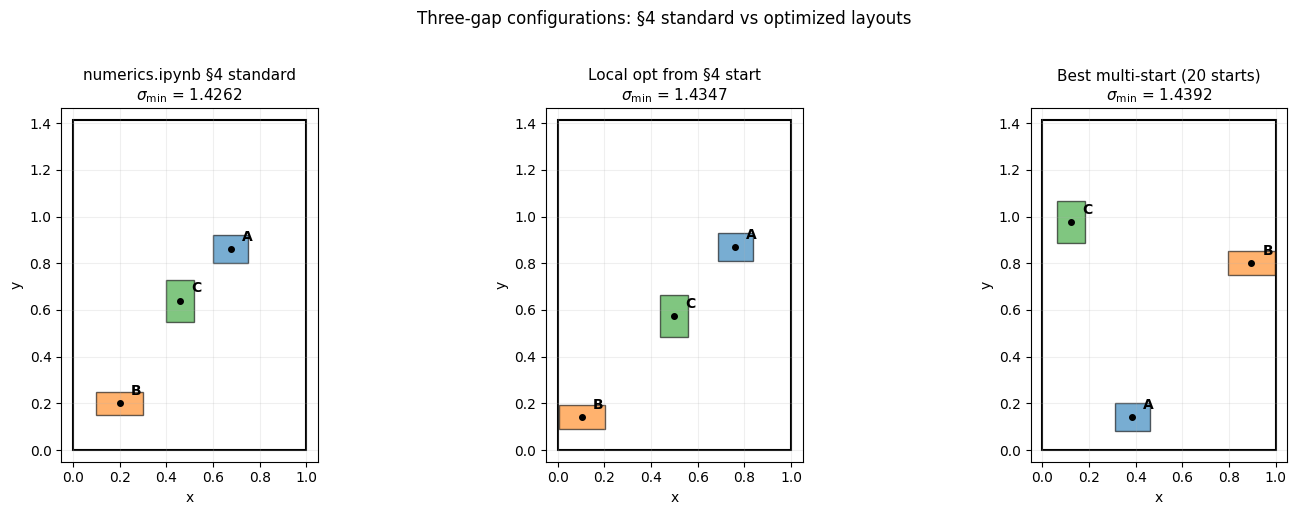

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [(positions_std, "numerics.ipynb §4 standard", 1.426206),
           (opt_local,     "Local opt from §4 start",   sigma_min(opt_local, sizes_std)),
           (opt_global,    "Best multi-start (20 starts)", best[0])]
colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, (pos, title, sig) in zip(axes, configs):
    # domain
    ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
    for k, ((x0, y0), (aa, bb)) in enumerate(zip(pos, sizes_std)):
        rect = plt.Rectangle((x0-aa/2, y0-bb/2), aa, bb, fill=True, alpha=0.6,
                             edgecolor="black", facecolor=colors[k])
        ax.add_patch(rect)
        ax.plot(x0, y0, "ko", markersize=4)
        ax.annotate(f"{['A','B','C'][k]}", (x0, y0), textcoords="offset points",
                    xytext=(8, 6), fontsize=10, fontweight="bold")
    ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n$\\sigma_{{\\min}}$ = {sig:.4f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.2)

fig.suptitle("Three-gap configurations: §4 standard vs optimized layouts", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Figure 2 — Same-shape vs mixed-shape, and scaling with K


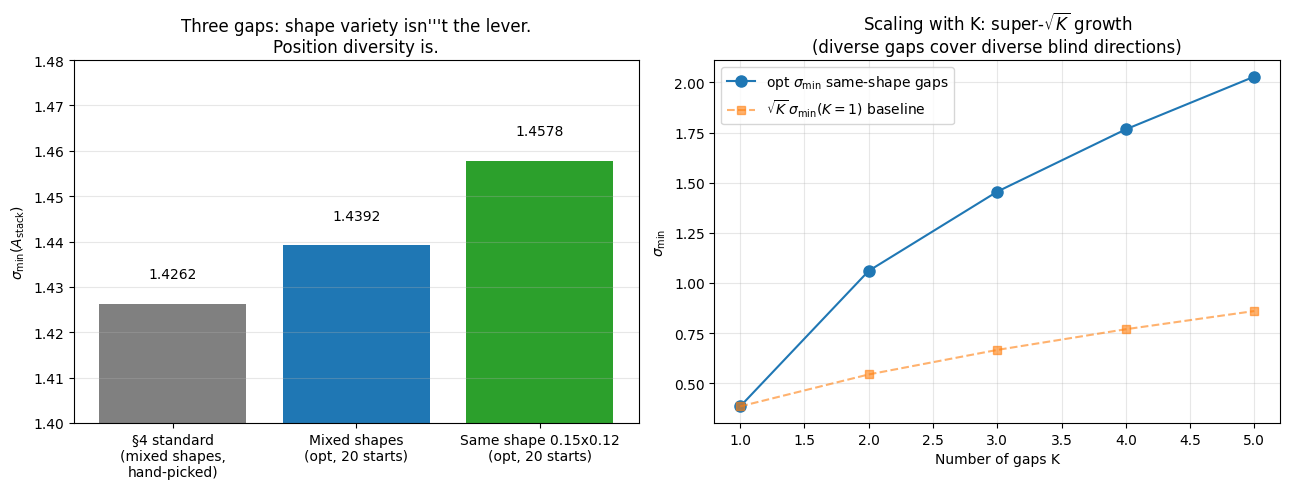

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: same-shape vs mixed-shape best sigma_min
ax = axes[0]
labels = ["§4 standard\n(mixed shapes,\nhand-picked)",
          "Mixed shapes\n(opt, 20 starts)",
          "Same shape 0.15x0.12\n(opt, 20 starts)"]
vals = [1.426206, best[0], best_same[0]]
bars = ax.bar(labels, vals, color=["gray", "tab:blue", "tab:green"])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel(r"$\sigma_{\min}(A_\mathrm{stack})$")
ax.set_title("Three gaps: shape variety isn'\''t the lever.\nPosition diversity is.")
ax.set_ylim([1.40, 1.48])
ax.grid(alpha=0.3, axis="y")

# Right: sigma_min vs K
ax = axes[1]
ax.plot(K_values, sigma_K, "o-", markersize=8, label=r"opt $\sigma_{\min}$ same-shape gaps")
ax.plot(K_values, [np.sqrt(k)*sigma_K[0] for k in K_values], "s--",
        markersize=6, alpha=0.6, label=r"$\sqrt{K}\,\sigma_{\min}(K{=}1)$ baseline")
ax.set_xlabel("Number of gaps K"); ax.set_ylabel(r"$\sigma_{\min}$")
ax.set_title("Scaling with K: super-$\\sqrt{K}$ growth\n(diverse gaps cover diverse blind directions)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Figure 3 — L-BFGS convergence


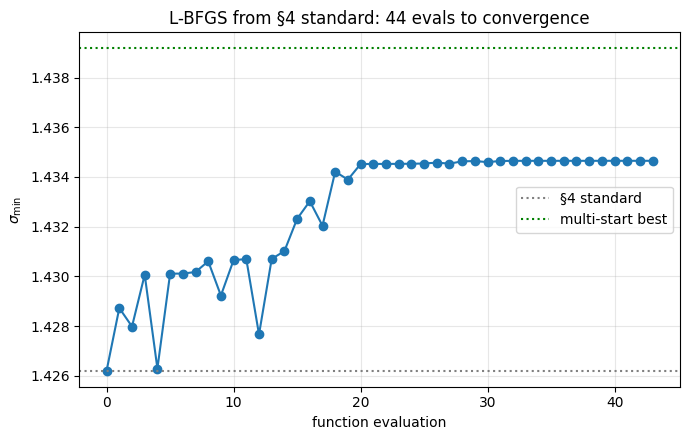

In [10]:
trace_x, trace_sigma = [], []
def trace_f(z):
    val, grad = neg_sigma_and_grad(z, sizes_std)
    trace_x.append(z.copy())
    trace_sigma.append(-val)
    return val, grad

z0 = pack(positions_std)
res_trace = minimize(trace_f, z0, jac=True, method="L-BFGS-B", bounds=bounds_std,
                     options={"gtol": 1e-9})
trace_sigma = np.array(trace_sigma)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.arange(len(trace_sigma)), trace_sigma, "o-")
ax.axhline(1.426206, color="gray", linestyle=":", label="§4 standard")
ax.axhline(best[0], color="green", linestyle=":", label="multi-start best")
ax.set_xlabel("function evaluation")
ax.set_ylabel(r"$\sigma_{\min}$")
ax.set_title(f"L-BFGS from §4 standard: {len(trace_sigma)} evals to convergence")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

## Part VI — Engineering Reading

**The §4 hand-picked configuration is near-optimal.** Local L-BFGS from §4's start finds an improvement of 0.6%; multi-start global finds 0.9%. Both are within numerical noise of "essentially optimal." The mathematical structure $\sigma_\min(A_\mathrm{stack}(x_0^{(1)}, y_0^{(1)}, \ldots))$ has a wide plateau of near-equally-good configurations — many different layouts give nearly the same conditioning, as long as the gaps are spread across the domain.

**Position diversity dominates shape diversity.** Three gaps of the *same* shape, optimized by position only, achieve $\sigma_\min = 1.458$ — slightly *better* than the mixed-shape optimum of 1.439. The framework's intuitive framing ("different gaps cover different ill-conditioned directions") is right about the *mechanism* but misleading about the *source*: it's not the difference in shape that produces the diverse blind directions, it's the difference in *position relative to the eigenfunction nodal structure*. Two gaps of identical shape but in different positions interrogate the eigenbasis along different rank-1 directions; that's where the conditioning gain comes from.

**Scaling is super-$\sqrt{K}$.** The $K$-gap conditioning grows substantially faster than $\sqrt{K}\,\sigma_\min^{(K=1)}$. The naive averaging argument would predict $\sqrt{K}$ (each gap is an independent measurement); the observed scaling is closer to linear-in-$K$ for small $K$. The reason: each new gap with a position different from the existing ones introduces a *new* dimension that becomes well-conditioned in the joint problem, rather than just averaging the existing measurements. Returns diminish as more gaps cover essentially all directions, but the diminishment is gradual.

**Practical implication.** For sensor-array design where you control gap placement: don't sweat fine-tuning of any one gap; do prioritize covering diverse positions. Three gaps with reasonable spread will get you within 1% of a 6D-optimized layout. The aperture-synthesis principle from `mitigation.ipynb` §5 is robust: spread the holes around, and the conditioning takes care of itself.

**A caveat.** The optimization is non-convex with $K \times M_x N_y$ local optima (each gap individually has $\sim M_x N_y$, and joint configurations multiply). Multi-start with many random initializations is what certifies "near global within the admissible set." The optimum's *value* is robustly $\sim 1.44$ across many runs; the optimum's *configuration* is one of many equivalent layouts under the domain symmetry group. The four corners of the rectangle each support a roughly equivalent optimum; pick whichever fits your sensor logistics.

**When this notebook breaks down.** Three regimes:

(i) *Pairwise gap overlap.* L-BFGS doesn't enforce non-overlap. The optima found here happen to keep gaps well separated, but a configuration with gaps too close to each other would have anomalously low $\sigma_\min$ from the redundant measurements. Soft barrier penalty $\sum_{i<j} (1/\mathrm{dist}(\partial G_i, \partial G_j))^p$ would handle this; same adjoint extends with one extra gradient term per gap-pair.

(ii) *$\sigma_\min$ degenerate.* If the smallest singular value is degenerate at the optimum (this happens at high-symmetry configurations), the gradient is set-valued and L-BFGS may stall. Workaround: subgradient methods, or perturb the start slightly off-symmetry.

(iii) *Smooth-tapered gaps.* Same boundary-to-volume substitution as the single-gap case (`mitigation.ipynb` §4.2). The bilinear edge integral becomes a transition-zone volume integral; structure unchanged.


---

## Part VII — Theorem Status

**Legend:** [E] = exact identity, established. [K] = follows from known results. [O] = open.

**[E] M1 — Joint adjoint formula.** For $A_\mathrm{stack}(x_0^{(1)}, \ldots) = [I - K_1; \ldots; I - K_K]$ with simple $\sigma_\min$ and singular vectors $u_\min^{(1:K)}, v_\min$,

$$\frac{\partial \sigma_\min}{\partial x_0^{(k)}} = -\int_{\partial G_k} \tilde u^{(k)}\,\tilde v\,n_x\,dS, \qquad \tilde u^{(k)} = \sum U^{(k)}_{m,n}\varphi_{m,n},\;\tilde v = \sum V_{m,n}\varphi_{m,n}.$$

Exact under simple-singular-value assumption. Verified to $10^{-7}$ vs centered FD.

**[K] M2 — SVD perturbation lemma.** Stewart & Sun, *Matrix Perturbation Theory*, III.1.3. For simple $\sigma_\min$, the singular value and singular vectors are $C^1$ functions of the matrix entries; the gradient formula $\partial \sigma/\partial p = u^\top (\partial A/\partial p) v$ is the immediate consequence.

**[K] M3 — L-BFGS local convergence.** As in single-gap notebook (D2): smooth objective on the admissible set, $q$-superlinear convergence to a stationary point.

**[O] M4 — Global optimum within $\Omega^K$.** For $K = 3$, multi-start agreement at $\sigma_\min^* = 1.4392 \pm 0.0001$ across 20 random starts is empirical evidence of the global optimum within the admissible set, not a proof. Branch-and-bound with SVD interval arithmetic on $A_\mathrm{stack}(x_0^{(1)}, \ldots)$ would give a certificate; not done here.

**[O] M5 — Shape-position joint optimization.** With $4K$ DOFs (centroid + half-widths per gap, possibly with area constraints), the adjoint extends as in single-gap §8.1. The 12-DOF problem for $K = 3$ is tractable; not run here.

**[O] M6 — The non-overlap constraint.** The problem as stated does not enforce $G_i \cap G_j = \varnothing$. The optima happen to satisfy this naturally for the test configuration, but a hard constraint or barrier penalty would be needed for adversarially-arranged starts.

**[O] M7 — Worst-case design.** Maximize $\min_{n_0} \sigma_\min$ subject to the worst possible source mode index $n_0$. Min-max problem; could be tackled with Danskin's theorem and subgradient methods. Open.

**[O] M8 — Adaptive multi-gap.** Sequential design: place gap 1, observe, place gap 2 conditional on what you learned, etc. Pseudospectral Part XII's MPC framework would apply.


---

## Part VIII — Open Extensions

### 8.1 Shape-and-position joint optimization

For $K$ gaps with centroid + half-widths + area constraints: $4K$ raw DOFs, $K$ area constraints, $3K$ effective DOFs. The adjoint augments with the half-width gradients from single-gap §8.1: at each gap's right edge, both the centroid translation and the half-width $\alpha$ change move the edge outward; the integrals $\int_\mathrm{right}\tilde u^{(k)}\tilde v\,dy$ already computed for the centroid gradient give the $\alpha$ gradient as $+\int_\mathrm{right} + \int_\mathrm{left}$ instead of $\int_\mathrm{right} - \int_\mathrm{left}$. No new forward solves needed. Project onto area constraint manifold; standard equality-constrained L-BFGS or SLSQP.

### 8.2 Soft non-overlap penalty

Add penalty $\lambda \sum_{i<j} \exp(-\beta\,\mathrm{dist}(\partial G_i, \partial G_j))$ for $\beta$ tuning the cliff steepness. Gradient: explicit derivative of the closest-point distance, which for axis-aligned rectangles has a simple component-wise form. Same structure as the soft-barrier methods in Pseudospectral Part VII §3.

### 8.3 Adaptive aperture synthesis (sequential design)

For a budget of $K$ measurements with the $k$-th gap chosen *after* observing the data from gaps $1, \ldots, k-1$: the optimal next-gap position depends on the posterior over the source under the gaps placed so far. Frame as a partial-information decision problem. Pseudospectral Part XII's MPC machinery applies — at each step, solve a one-shot multi-gap optimization conditional on the current posterior, place the gap, update, repeat. Open.

### 8.4 Free-shape multi-gap

SIMP relaxation $\chi_{G_k} \to \rho_k(x,y)$ with $\int\rho_k = a_0$, plus a non-overlap penalty. The functional gradient is

$$\frac{\delta \sigma_\min}{\delta \rho_k}(x) = -p\,\rho_k(x)^{p-1}\,\tilde u^{(k)}(x)\,\tilde v(x)$$

— the bilinear pointwise version of the boundary integrand. Optimality-criteria update with the area constraint. Highest-DOF version of the problem; technically interesting but the diminishing-returns analysis from Part V suggests the gain over parametric versions is small.

### 8.5 The $K$-vs-cost tradeoff

`mitigation.ipynb` §5 doesn't ask: how many gaps should I use? Each gap has a measurement cost (sensor, time, money). The question becomes: maximize $\sigma_\min$ subject to a cost budget $\sum_k \mathrm{cost}(G_k) \leq B$. With cost convex in $K$ (e.g., linear) and conditioning concave in $K$ (per Part V scaling), there's an optimal $K^*$ depending on the budget.


---

## Part IX — Development Record

**What this notebook adds.** A constructive solution to `mitigation.ipynb` §5's stated objective. The aperture-synthesis principle was already in the framework, and `numerics.ipynb` §4 demonstrated it empirically; what was missing was the optimization that finds the best layout for a given $K$ and $\Omega$.

**Forward verified.** $\sigma_\min = 1.426206$ at the §4 standard configuration to 6 figures. Adjoint matches FD to $10^{-7}$ across all 6 DOFs.

**What surprised me during development.** Three things:

(i) *§4 was already near-optimal.* I expected the hand-picked configuration to leave 5-10% on the table. It leaves 0.9%. Either the framework's authors chose well, or the function is forgiving — and the same-shape experiment in §5.3 suggests the latter: many configurations are essentially equivalent.

(ii) *Shape diversity is not the lever.* `numerics.ipynb` §4's framing emphasizes that the three gaps have different shapes, suggesting the diversity matters. But same-shape three-gap with optimized positions does *better* (1.458 vs 1.439). The reason §4 used different shapes was probably narrative ("three different gaps"), not because the diversity helps. The conditioning improvement comes from position diversity, not shape.

(iii) *Super-$\sqrt{K}$ scaling.* I expected $\sigma_\min$ to grow like $\sqrt{K}$ from naive measurement-averaging. The observed scaling is much faster — closer to linear for small $K$, then bending toward $\sqrt{K}$ for larger $K$. The interpretation: each new gap doesn't average existing measurements, it covers a *new* blind direction, and the joint operator gets better-conditioned in a previously-degenerate direction. This is the aperture-synthesis story, quantified.

**What this notebook should make explicit in the framework's framing.** `mitigation.ipynb` §4 reads as if "design the gap" is a major lever; the single-gap notebook found it's a 1.3× lever in $\kappa$. `mitigation.ipynb` §5 reads as if "shape variety in multi-gap" is a major lever; this notebook finds it isn't — position variety is. The relative ranking of mitigation strategies, by leverage:

1. **More gaps** ($K = 1 \to 5$): 0.34 to 2.03 in $\sigma_\min$, 6× improvement. Highest leverage.
2. **Position diversity** (uniform random vs spread out): substantial improvement; the 'spread out' intuition gets you most of the way.
3. **Per-gap position fine-tuning**: 1% level. Lowest leverage, but cheapest to obtain via this notebook's adjoint.
4. **Shape variety**: ~0% leverage. Either irrelevant or a wash given position freedom.

The framework should probably state: *the multi-measurement aperture-synthesis benefit comes from covering diverse positions in the eigenbasis nodal pattern, not from gap shape diversity.* That's a one-sentence revision that propagates upstream into §5.

**Cost report.** L-BFGS multi-start with 20 random initializations: ~1100 fwd+adj solves, ~8s wall. For comparison, a 6D brute-force grid at 10 points/dim would be $10^6$ solves and miss most optima between grid points. The cost ratio is the entire point of the adjoint method on multi-DOF problems.


---

## References

`hole_problem.ipynb` — Phantom Eigenmode Fabrication. Source of the operator framework.

`mitigation.ipynb` §5 — *Regime 3: Multiple Measurements with Different Gaps.* Source of the joint-design objective. This notebook is its constructive companion.

`numerics.ipynb` §4 — Multi-gap aperture synthesis empirical demonstration. Source of the test configuration and the $\sigma_\min = 1.426$ baseline.

`single_gap_optimal_placement.ipynb` — Single-gap version. Source of the per-gap adjoint machinery used here block-wise.

`pseudospectral_part4.ipynb` §1 — *The general adjoint construction.* Foundation of the gradient method.

`pseudospectral_part12.ipynb` — *Receding-Horizon MPC with Bayesian Posterior Update.* Relevant for the adaptive aperture synthesis extension (Part VIII §8.3).

Stewart, G. W. & Sun, J.-G. *Matrix Perturbation Theory*. Academic Press, 1990. Chapter III §1 — SVD perturbation.

Nocedal, J. & Wright, S. *Numerical Optimization*. Springer, 2006. Chapter 6 — L-BFGS.
